In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('BreadBasket_DMS.csv')

In [59]:
df

,Transaction,Item
0,1,Bread
1,2,"Scandinavian,Scandinavian"
2,3,"Hot chocolate,Jam,Cookies"
3,4,Muffin
4,5,"Coffee,Pastry,Bread"
...,...,...
9460,9680,Bread
9461,9681,"Truffles,Tea,Spanish Brunch,Christmas common"
9462,9682,"Muffin,Tacos/Fajita,Coffee,Tea"
9463,9683,"Coffee,Pastry"


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21293 entries, 0 to 21292
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         21293 non-null  object
 1   Time         21293 non-null  object
 2   Transaction  21293 non-null  int64 
 3   Item         21293 non-null  object
dtypes: int64(1), object(3)
memory usage: 665.5+ KB


In [62]:
top_items = df.stack().value_counts().sum()
top_items

np.int64(18930)

In [58]:
i=df['Item'].tolist()


In [18]:
df=df.drop(df.loc[df['Item'] == 'NONE'].index)
df.loc[df['Item']=='NONE'].count()

Date           0
Time           0
Transaction    0
Item           0
dtype: int64

In [19]:
count = df['Item'].value_counts()
count
df['Item'].unique().tolist()

['Bread',
 'Scandinavian',
 'Hot chocolate',
 'Jam',
 'Cookies',
 'Muffin',
 'Coffee',
 'Pastry',
 'Medialuna',
 'Tea',
 'Tartine',
 'Basket',
 'Mineral water',
 'Farm House',
 'Fudge',
 'Juice',
 "Ella's Kitchen Pouches",
 'Victorian Sponge',
 'Frittata',
 'Hearty & Seasonal',
 'Soup',
 'Pick and Mix Bowls',
 'Smoothies',
 'Cake',
 'Mighty Protein',
 'Chicken sand',
 'Coke',
 'My-5 Fruit Shoot',
 'Focaccia',
 'Sandwich',
 'Alfajores',
 'Eggs',
 'Brownie',
 'Dulce de Leche',
 'Honey',
 'The BART',
 'Granola',
 'Fairy Doors',
 'Empanadas',
 'Keeping It Local',
 'Art Tray',
 'Bowl Nic Pitt',
 'Bread Pudding',
 'Adjustment',
 'Truffles',
 'Chimichurri Oil',
 'Bacon',
 'Spread',
 'Kids biscuit',
 'Siblings',
 'Caramel bites',
 'Jammie Dodgers',
 'Tiffin',
 'Olum & polenta',
 'Polenta',
 'The Nomad',
 'Hack the stack',
 'Bakewell',
 'Lemon and coconut',
 'Toast',
 'Scone',
 'Crepes',
 'Vegan mincepie',
 'Bare Popcorn',
 'Muesli',
 'Crisps',
 'Pintxos',
 'Gingerbread syrup',
 'Panatone',
 'B

In [20]:
basket_items={}
for item in df['Item']:
    if item in basket_items:
        basket_items[item] = basket_items[item] + 1
    else:
        basket_items[item] = 1
basket_items

{'Bread': 3325,
 'Scandinavian': 277,
 'Hot chocolate': 590,
 'Jam': 149,
 'Cookies': 540,
 'Muffin': 370,
 'Coffee': 5471,
 'Pastry': 856,
 'Medialuna': 616,
 'Tea': 1435,
 'Tartine': 47,
 'Basket': 6,
 'Mineral water': 136,
 'Farm House': 374,
 'Fudge': 159,
 'Juice': 369,
 "Ella's Kitchen Pouches": 17,
 'Victorian Sponge': 7,
 'Frittata': 81,
 'Hearty & Seasonal': 107,
 'Soup': 342,
 'Pick and Mix Bowls': 12,
 'Smoothies': 77,
 'Cake': 1025,
 'Mighty Protein': 11,
 'Chicken sand': 1,
 'Coke': 185,
 'My-5 Fruit Shoot': 18,
 'Focaccia': 54,
 'Sandwich': 771,
 'Alfajores': 369,
 'Eggs': 28,
 'Brownie': 379,
 'Dulce de Leche': 13,
 'Honey': 6,
 'The BART': 1,
 'Granola': 28,
 'Fairy Doors': 2,
 'Empanadas': 7,
 'Keeping It Local': 63,
 'Art Tray': 38,
 'Bowl Nic Pitt': 2,
 'Bread Pudding': 4,
 'Adjustment': 1,
 'Truffles': 193,
 'Chimichurri Oil': 2,
 'Bacon': 1,
 'Spread': 2,
 'Kids biscuit': 12,
 'Siblings': 2,
 'Caramel bites': 3,
 'Jammie Dodgers': 125,
 'Tiffin': 146,
 'Olum & pole

In [21]:
item_names = []
item_freq = []

for key,value in basket_items.items():
    item_names.append(key)
    item_freq.append(value)

<Axes: xlabel='Names'>

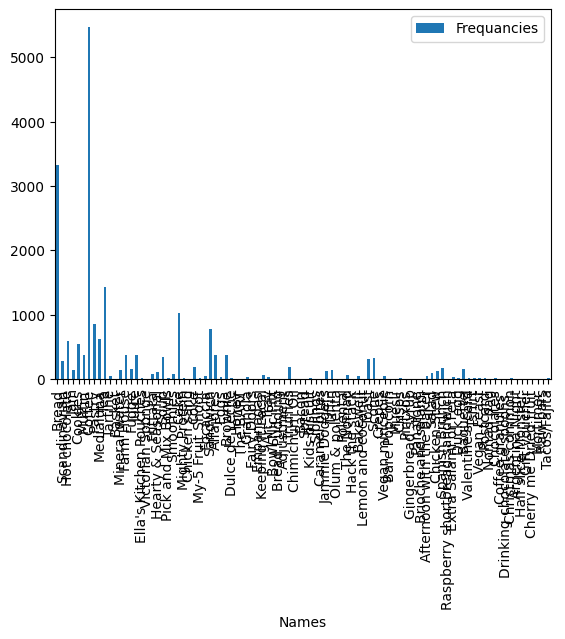

In [22]:
item_tabel = pd.DataFrame({'Names' : item_names, 'Frequancies' : item_freq})
item_tabel
item_tabel.plot.bar('Names','Frequancies')

<Axes: xlabel='Names'>

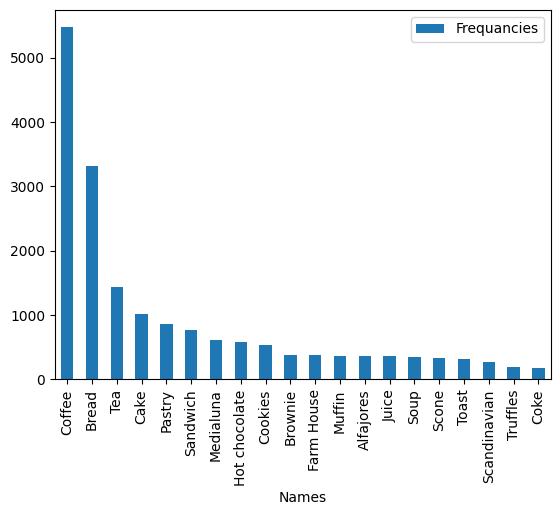

In [26]:
item_tabel.sort_values('Frequancies', ascending = False).head(20).\
plot.bar('Names','Frequancies')

In [27]:
df = df.groupby('Transaction').agg(','.join).reset_index()
df = df.drop(['Date','Time'], axis=1)
df

,Transaction,Item
0,1,Bread
1,2,"Scandinavian,Scandinavian"
2,3,"Hot chocolate,Jam,Cookies"
3,4,Muffin
4,5,"Coffee,Pastry,Bread"
...,...,...
9460,9680,Bread
9461,9681,"Truffles,Tea,Spanish Brunch,Christmas common"
9462,9682,"Muffin,Tacos/Fajita,Coffee,Tea"
9463,9683,"Coffee,Pastry"


In [28]:
items_data=df['Item']
items_data

0                                              Bread
1                          Scandinavian,Scandinavian
2                          Hot chocolate,Jam,Cookies
3                                             Muffin
4                                Coffee,Pastry,Bread
                            ...                     
9460                                           Bread
9461    Truffles,Tea,Spanish Brunch,Christmas common
9462                  Muffin,Tacos/Fajita,Coffee,Tea
9463                                   Coffee,Pastry
9464                                       Smoothies
Name: Item, Length: 9465, dtype: object

In [29]:
items_list = [item.split(',') for item in items_data]
item_list_df = pd.DataFrame({'Items':items_list})
item_list_df.head()


,Items
0,[Bread]
1,"[Scandinavian, Scandinavian]"
2,"[Hot chocolate, Jam, Cookies]"
3,[Muffin]
4,"[Coffee, Pastry, Bread]"


In [30]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

In [31]:
t = TransactionEncoder()
t_array = t.fit(items_list).transform(items_list)
t_array
df_encoded = pd.DataFrame(t_array, columns = t.columns_)
df_encoded

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9461,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9462,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
df_support = apriori(df_encoded, min_support=0.01, use_colnames = True)
df_support.shape

(61, 2)

In [33]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(df_support, metric='confidence',min_threshold = 0.1)

In [34]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Alfajores),(Bread),0.036344,0.327205,0.010354,0.284884,0.870657,1.0,-0.001538,0.940818,-0.133570,0.029315,-0.062904,0.158264
1,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
2,(Brownie),(Bread),0.040042,0.327205,0.010777,0.269129,0.822508,1.0,-0.002326,0.920538,-0.183536,0.030231,-0.086321,0.151032
3,(Cake),(Bread),0.103856,0.327205,0.023349,0.224822,0.687097,1.0,-0.010633,0.867923,-0.336947,0.057269,-0.152177,0.148091
4,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
5,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
6,(Cookies),(Bread),0.054411,0.327205,0.014474,0.266019,0.813004,1.0,-0.003329,0.916638,-0.195651,0.039424,-0.090943,0.155128
7,(Hot chocolate),(Bread),0.058320,0.327205,0.013418,0.230072,0.703144,1.0,-0.005665,0.873841,-0.309550,0.036059,-0.144373,0.135540
8,(Medialuna),(Bread),0.061807,0.327205,0.016904,0.273504,0.835879,1.0,-0.003319,0.926082,-0.173062,0.045429,-0.079818,0.162584
9,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884


In [38]:
#recommendation - must be shown the bread during pastry buying or making a combo of two for cross selling 
rules[rules['antecedents'] == {'Cake'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(Cake),(Bread),0.103856,0.327205,0.023349,0.224822,0.687097,1.0,-0.010633,0.867923,-0.336947,0.057269,-0.152177,0.148091
14,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
16,(Cake),(Hot chocolate),0.103856,0.058320,0.011410,0.109868,1.883874,1.0,0.005354,1.057910,0.523553,0.075683,0.054740,0.152760
18,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779


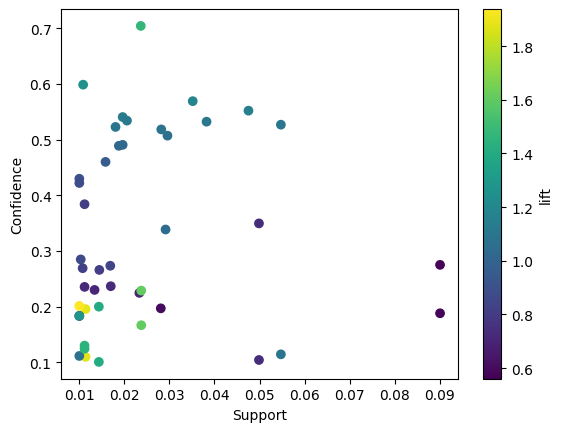

In [40]:
plt.scatter(rules['support'],rules['confidence'],c=rules['lift'],cmap='viridis')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.colorbar(label='lift')

In [44]:
# heatmap
import seaborn as sns
import pandas as pd

pivot = rules.pivot_table(index='antecedents',columns='consequents',values='lift')
pivot

consequents,(Bread),(Coffee),(Cake),(Hot chocolate),(Tea),(Sandwich),(Pastry),"(Coffee, Bread)"
antecedents,,,,,,,,
(Alfajores),0.870657,1.130235,NaN,NaN,NaN,NaN,NaN,NaN
"(Pastry, Bread)",NaN,0.802807,NaN,NaN,NaN,NaN,NaN,NaN
"(Pastry, Coffee)",0.719901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(Cake, Bread)",NaN,0.898557,NaN,NaN,NaN,NaN,NaN,NaN
"(Coffee, Bread)",NaN,NaN,1.073621,NaN,NaN,NaN,1.444872,NaN
"(Coffee, Cake)",0.560497,NaN,NaN,NaN,1.285822,NaN,NaN,NaN
(Toast),NaN,1.472431,NaN,NaN,NaN,NaN,NaN,NaN
(Spanish Brunch),NaN,1.251766,NaN,NaN,NaN,NaN,NaN,NaN
(Soup),NaN,0.961807,NaN,NaN,NaN,NaN,NaN,NaN


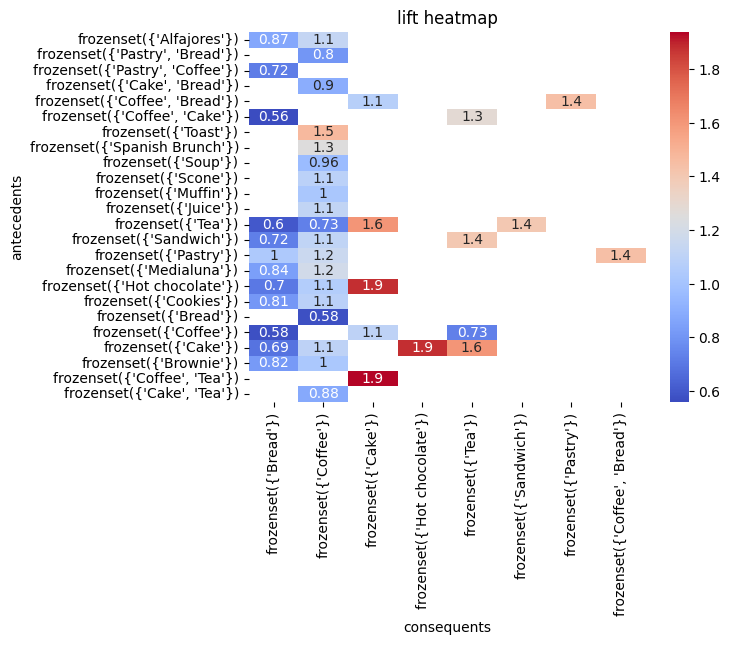

In [45]:
sns.heatmap(pivot,cmap='coolwarm',annot=True)
plt.title('lift heatmap')
plt.show()

In [52]:
# network graph
!pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- --------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import networkx as nx

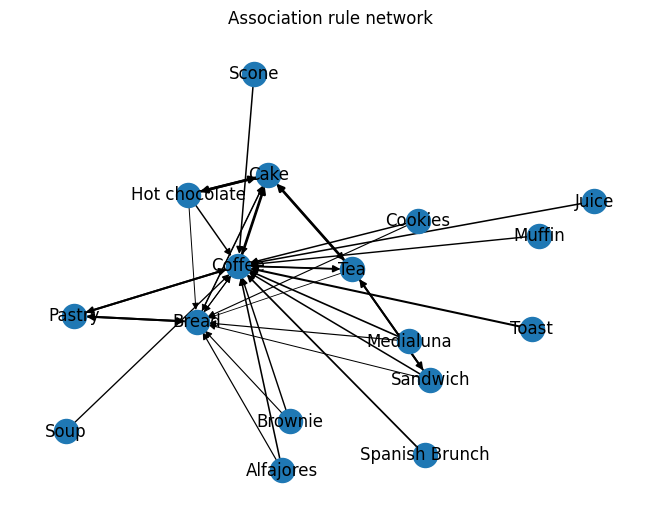

In [56]:
G = nx.DiGraph()
for _,row in rules.iterrows():
    for ant in row['antecedents']:
        for con in row['consequents']:
            G.add_edge(ant,con,weight=row['lift'])
pos = nx.spring_layout(G)
edges = G.edges(data=True)
weights = [d['weight'] for (_,_,d) in edges]
nx.draw(G,pos,with_labels=True,width=weights)
plt.title('Association rule network')
plt.show()

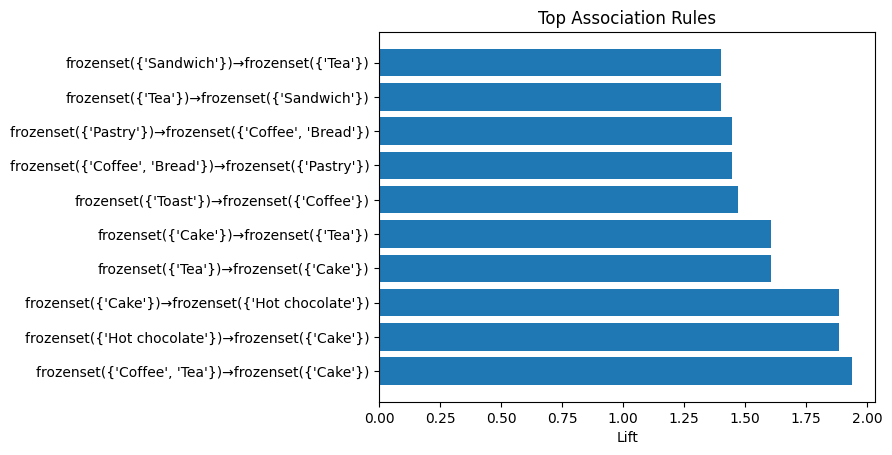

In [57]:
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.barh(range(len(top_rules)), top_rules['lift'])
plt.yticks(range(len(top_rules)), 
           [str(a) + "→" + str(c) 
            for a, c in zip(top_rules['antecedents'], top_rules['consequents'])])

plt.xlabel("Lift")
plt.title("Top Association Rules")
plt.show()